# Лабораторная работа №6 
# Построение и анализ границ для линейных блоковых кодов

## Описание:
В данной лабораторной работе исследуются асимптотические границы скорости линейных блоковых кодов (`Синглтона, Хэмминга, Гилберта-Варшамова`) в зависимости от относительного кодового расстояния $\delta = d/n$. 

Также реализуется программа для генерации случайных линейных кодов в систематической форме и проверки их параметров относительно теоретических пределов.

## Теоретическая справка:

Для двоичных линейных кодов ($q=2$) рассматриваются следующие границы скорости $R = k/n$ в зависимости от $\delta = d/n$:

1. **Граница Синглтона:** $R \le 1 - \delta$
2. **Граница Хэмминга (сферической упаковки):** $R \le 1 - H_2(\delta/2)$
3. **Граница Гилберта-Варшамова (GV):** $R \ge 1 - H_2(\delta)$ (гарантирует существование кодов)

Где $H_2(x) = -x \log_2 x - (1-x) \log_2 (1-x)$ — двоичная функция энтропии.

### Основные инструменты:

Используются функции для вычисления энтропии, генерации систематических матриц вида $G = [I | P]$ и полного перебора кодовых слов для нахождения минимального расстояния.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from tqdm import tqdm 

def binary_entropy(x):
    result = np.zeros_like(x)
    # Mask to avoid log(0) errors
    mask = (x > 0) & (x < 1)
    val = x[mask]
    result[mask] = -val * np.log2(val) - (1 - val) * np.log2(1 - val)
    return result

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Реализация алгоритмов:

1. `generate_systematic_matrix(n, k)` создает порождающую матрицу с гарантированно линейно независимыми строками.
2. `get_min_distance(G, k, n)` находит минимальный вес Хэмминга ненулевого кодового слова.

In [2]:
def generate_systematic_matrix(n, k):
    # Identity matrix k x k
    I = np.eye(k, dtype=int)
    
    # Random parity matrix k x (n-k)
    P = np.random.randint(0, 2, size=(k, n - k))
    
    # Stack them horizontally: G = [I | P]
    G = np.hstack((I, P))
    return G

def get_min_distance(G, k, n):
    min_weight = n
    limit = 1 << k
    
    # Iterate through all non-zero messages from 1 to 2^k - 1
    for i in range(1, limit):
        # Convert number to bit array (fast way)
        msg = np.array(list(np.binary_repr(i, width=k)), dtype=int)
        
        # Encode: u * G (mod 2)
        codeword = np.dot(msg, G) % 2
        
        w = np.sum(codeword)
        if w < min_weight:
            min_weight = w
            # Optimization: weight cannot be less than 1
            if min_weight == 1:
                return 1
                
    return min_weight

### Моделирование:

Запустим генерацию серии случайных кодов. Для каждого кода фиксируется длина $n$, но случайно выбирается размерность $k$, чтобы покрыть весь диапазон скоростей $R$.

In [3]:
def run_simulation(num_codes=50, n_fixed=20):
    results = [] 
    
    print(f"Starting generation of {num_codes} codes (length n={n_fixed})...")
    start_time = time.time()

    # Using tqdm for progress bar
    for _ in tqdm(range(num_codes)):
        # 1. Randomly choose k (from 3 to 15 to keep processing time reasonable)
        max_k = min(n_fixed - 1, 15) 
        k = random.randint(3, max_k)
        
        # 2. Generate matrix
        G = generate_systematic_matrix(n_fixed, k)
        
        # 3. Calculate d_min
        d = get_min_distance(G, k, n_fixed)
        
        # 4. Store results
        rate = k / n_fixed
        delta = d / n_fixed
        results.append((delta, rate))

    elapsed = time.time() - start_time
    print(f"Generation completed in {elapsed:.2f} sec.")
    return results

# Simulation parameters
TOTAL_CODES = 200
N_LENGTH = 80

data = run_simulation(TOTAL_CODES, N_LENGTH)

Starting generation of 200 codes (length n=80)...


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [00:08<00:00, 23.20it/s]

Generation completed in 8.63 sec.


### Построение графиков и анализ результатов:

На графике отображены теоретические границы и полученное облако точек для случайных кодов.

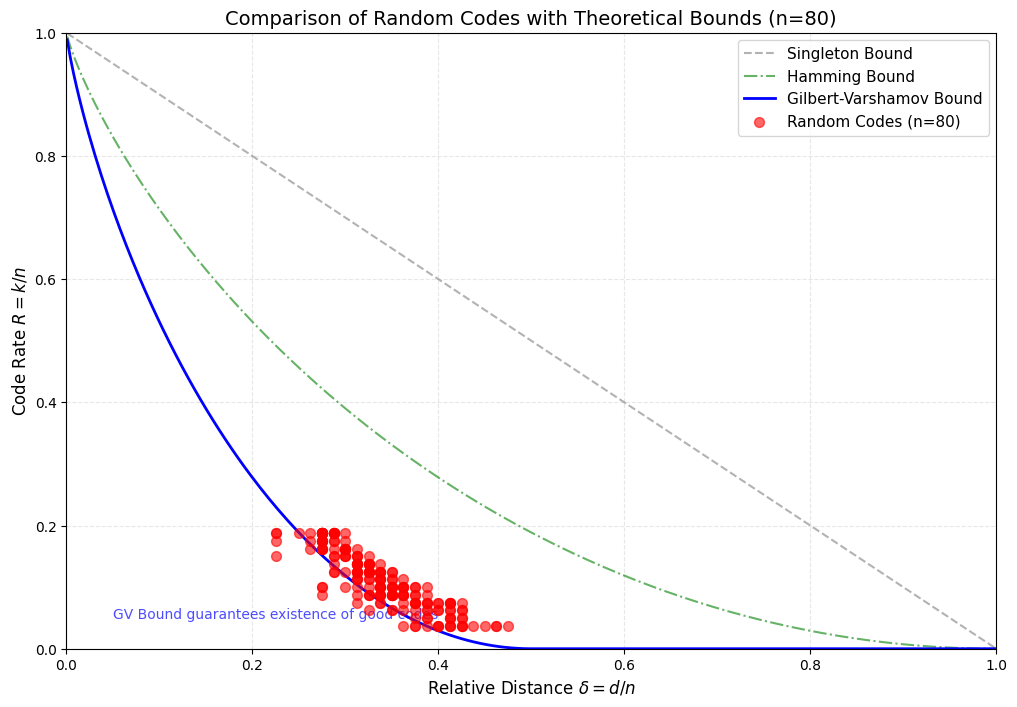

In [4]:
plt.figure(figsize=(12, 8))

# 1. Plot Theoretical Bounds
delta_x = np.linspace(0.001, 0.999, 300)

# Singleton: R <= 1 - delta
plt.plot(delta_x, np.maximum(1 - delta_x, 0), '--', color='gray', alpha=0.6, label='Singleton Bound')

# Hamming: R <= 1 - H(delta/2)
plt.plot(delta_x, 1 - binary_entropy(delta_x / 2), '-.', color='green', alpha=0.6, label='Hamming Bound')

# Gilbert-Varshamov: R >= 1 - H(delta)
gv_y = np.zeros_like(delta_x)
mask = delta_x < 0.5
gv_y[mask] = 1 - binary_entropy(delta_x[mask])
plt.plot(delta_x, gv_y, '-', color='blue', linewidth=2, label='Gilbert-Varshamov Bound')

# 2. Plot Random Codes
deltas = [p[0] for p in data]
rates = [p[1] for p in data]

plt.scatter(deltas, rates, color='red', s=50, alpha=0.6, zorder=5, label=f'Random Codes (n={N_LENGTH})')

# Plot styling
plt.title(f'Comparison of Random Codes with Theoretical Bounds (n={N_LENGTH})', fontsize=14)
plt.xlabel('Relative Distance $\delta = d/n$', fontsize=12)
plt.ylabel('Code Rate $R = k/n$', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=11)

# Annotation
plt.text(0.05, 0.05, "GV Bound guarantees existence of good codes", fontsize=10, color='blue', alpha=0.7)

plt.show()

## Вывод
В данной лабораторной работе мы изучили расположение линейных кодов на плоскости $R(\delta)$ относительно теоретических асимптотических границ (`Гильберта-Варшамова, Хемминга, Синглтона`). Была произведена генерация случайных `TOTAL_CODES` линейных кодов по матрице порождения `G` с длиной $k < n$. По графику видно, что при малых $n$ точки кодов разбросаны по всей ограниченной области, часть из них при этом выпадает из нее. С увеличением же длины кода эти точки собираются более компактно, прижимаясь к границе Гильберта-Варшамова. Это объясняется тем, что при устремлении $n \to \infty$ эта кривая отвечает за случайные коды со средней плотностью упаковки.